In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
print("hi")

hi


In [ ]:
import os
import zipfile
import gdown


GDRIVE_FILE_ID = '1ZEyNMEO43u3qhJAwJeBZxFBEYc_pVYZQ' 
output = 'dataset.zip'

if not os.path.exists(output):
    # Using the direct download confirmation bypass
    url = f'https://drive.google.com/uc?id={GDRIVE_FILE_ID}'
    gdown.download(url, output, quiet=False, fuzzy=True)

EXTRACT_DIR = 'deeplense_data'
if not os.path.exists(EXTRACT_DIR):
    print("Extracting data... this may take a minute.")
    with zipfile.ZipFile(output, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)
    print("Extraction Complete!")
else:
    print("Dataset already extracted.")

Downloading...
From (original): https://drive.google.com/uc?id=1ZEyNMEO43u3qhJAwJeBZxFBEYc_pVYZQ
From (redirected): https://drive.google.com/uc?id=1ZEyNMEO43u3qhJAwJeBZxFBEYc_pVYZQ&confirm=t&uuid=045de77a-4250-488e-85a0-5df77ce2a7ec
To: /kaggle/working/dataset.zip
100%|██████████| 1.13G/1.13G [00:11<00:00, 96.1MB/s]


Extracting data... this may take a minute.
Extraction Complete!


In [ ]:
import os
import glob
import numpy as np
import torch
from torch.utils.data import DataLoader, Dataset, Subset
from sklearn.model_selection import train_test_split

# STEP 1: TARGETED FOLDER MAPPING
def get_deeplense_data(base_path):
    # Mapping based on your 'ls' output
    mapping = {
        'no': 0,      # No sub
        'sphere': 1,  # Subhalo
        'vort': 2     # Vortex
    }
    
    all_files = []
    # Search in both train and val folders 
    for split in ['train', 'val']:
        for folder_name, label_idx in mapping.items():
            # Construct path: deeplense_data/dataset/train/no, etc.
            folder_path = os.path.join(base_path, 'dataset', split, folder_name)
            
            if os.path.exists(folder_path):
                files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith('.npy')]
                for f in files:
                    all_files.append((f, label_idx))
                print(f"Found {len(files)} files in {split}/{folder_name}")
            else:
                print(f" Path not found: {folder_path}")
    
    return all_files

# Execute discovery
data_list = get_deeplense_data('deeplense_data')

if not data_list:
    raise ValueError("Still no files found. Check if 'deeplense_data/dataset' exists.")


class LensingDataset(Dataset):
    def __init__(self, data_list):
        self.data_list = data_list
        
    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        img_path, label = self.data_list[idx]
        image = np.load(img_path).astype(np.float32)
        image = np.squeeze(image) # Ensure (H, W)
        
        # Normalization
        img_min, img_max = image.min(), image.max()
        if img_max > img_min:
            image = (image - img_min) / (img_max - img_min)
            
        return torch.from_numpy(image).unsqueeze(0), torch.tensor(label)

# 90:10 Stratified Split
labels = [x[1] for x in data_list]
train_idx, val_idx = train_test_split(
    list(range(len(data_list))), 
    test_size=0.1, 
    stratify=labels, 
    random_state=42
)

train_loader = DataLoader(Subset(LensingDataset(data_list), train_idx), batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(Subset(LensingDataset(data_list), val_idx), batch_size=32, shuffle=False, num_workers=2)

print(f"\n Ready to train! Total images: {len(data_list)}")

Found 10000 files in train/no
Found 10000 files in train/sphere
Found 10000 files in train/vort
Found 2500 files in val/no
Found 2500 files in val/sphere
Found 2500 files in val/vort

✅ Ready to train! Total images: 37500


In [ ]:
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
from sklearn.metrics import roc_auc_score, accuracy_score

class PhysicsLayer(nn.Module):
    def __init__(self):
        super().__init__()
        self.alpha_scale = nn.Parameter(torch.tensor([0.15])) # Learnable lensing strength

    def forward(self, x, deflection):
        B, _, H, W = x.size()
        # Generate coordinate grid
        grid_y, grid_x = torch.meshgrid(torch.linspace(-1, 1, H), torch.linspace(-1, 1, W), indexing='ij')
        grid = torch.stack((grid_x, grid_y), 2).unsqueeze(0).to(x.device).repeat(B, 1, 1, 1)
        
        # Ray-tracing: Source_pos = Image_pos - alpha
        v_grid = torch.clamp(grid - self.alpha_scale * deflection, -1, 1)
        return F.grid_sample(x, v_grid, align_corners=True, mode='bilinear')

class DeepLensePINN(nn.Module):
    def __init__(self):
        super().__init__()
        # Backbone for feature extraction
        self.backbone = models.efficientnet_b0(weights='IMAGENET1K_V1')
        self.backbone.features[0][0] = nn.Conv2d(1, 32, 3, stride=2, padding=1, bias=False)
        
        # Physics Branch (Potential Field estimation)
        self.deflection_net = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 2, 3, padding=1),
            nn.Tanh()
        )
        self.physics_engine = PhysicsLayer()
        
        # High-capacity classifier
        self.classifier = nn.Sequential(
            nn.Linear(1000 + 1000, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 3)
        )

    def forward(self, x):
        feat_orig = self.backbone(x)
        # Physics correction pass
        defl = self.deflection_net(x).permute(0, 2, 3, 1)
        source_recon = self.physics_engine(x, defl)
        feat_phys = self.backbone(source_recon)
        
        return self.classifier(torch.cat((feat_orig, feat_phys), dim=1))

# InitializING
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DeepLensePINN().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

print("Starting Training Session.")

for epoch in range(15):
    model.train()
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), lbls)
        loss.backward()
        optimizer.step()

    # Evaluation
    model.eval()
    all_lbls, all_probs = [], []
    with torch.no_grad():
        for imgs, lbls in val_loader:
            outputs = model(imgs.to(device))
            all_probs.append(F.softmax(outputs, dim=1).cpu().numpy())
            all_lbls.append(lbls.numpy())
    
    y_true = np.concatenate(all_lbls)
    y_pred = np.concatenate(all_probs)
    acc = accuracy_score(y_true, np.argmax(y_pred, axis=1))
    auc = roc_auc_score(y_true, y_pred, multi_class='ovr')
    
    print(f"Epoch {epoch+1:02d} | Accuracy: {acc:.4f} | AUC: {auc:.4f}")

torch.save(model.state_dict(), 'DeepLense_PINN_Final.pth')

Starting Training Session.
Epoch 01 | Accuracy: 0.3363 | AUC: 0.5413
Epoch 02 | Accuracy: 0.3779 | AUC: 0.6236
Epoch 03 | Accuracy: 0.4749 | AUC: 0.6892
Epoch 04 | Accuracy: 0.5472 | AUC: 0.7503
Epoch 05 | Accuracy: 0.6120 | AUC: 0.8164
Epoch 06 | Accuracy: 0.6939 | AUC: 0.8636
Epoch 07 | Accuracy: 0.6557 | AUC: 0.8439
Epoch 08 | Accuracy: 0.6669 | AUC: 0.8550
Epoch 09 | Accuracy: 0.6376 | AUC: 0.8490
Epoch 10 | Accuracy: 0.6453 | AUC: 0.8720
Epoch 11 | Accuracy: 0.6443 | AUC: 0.8774
Epoch 12 | Accuracy: 0.7000 | AUC: 0.8924
Epoch 13 | Accuracy: 0.6341 | AUC: 0.8725
Epoch 14 | Accuracy: 0.6205 | AUC: 0.8740
Epoch 15 | Accuracy: 0.6549 | AUC: 0.8740


In [15]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model.eval()
y_true_list, y_probs_list = [], []

with torch.no_grad():
    for imgs, lbls in val_loader:
        outputs = model(imgs.to(device))
        y_probs_list.append(F.softmax(outputs, dim=1).cpu().numpy())
        y_true_list.append(lbls.numpy())

y_true = np.concatenate(y_true_list)
y_probs = np.concatenate(y_probs_list)
y_pred = np.argmax(y_probs, axis=1)

print("--- FINAL GSOC EVALUATION REPORT ---")
print(classification_report(y_true, y_pred, target_names=['No Sub', 'Subhalo', 'Vortex']))
final_auc = roc_auc_score(y_true, y_probs, multi_class='ovr')
print(f"FINAL SUBMISSION AUC: {final_auc:.4f}")

--- FINAL GSOC EVALUATION REPORT ---
              precision    recall  f1-score   support

      No Sub       0.76      0.80      0.78      1250
     Subhalo       0.94      0.28      0.44      1250
      Vortex       0.54      0.88      0.67      1250

    accuracy                           0.65      3750
   macro avg       0.74      0.65      0.63      3750
weighted avg       0.74      0.65      0.63      3750

FINAL SUBMISSION AUC: 0.8740


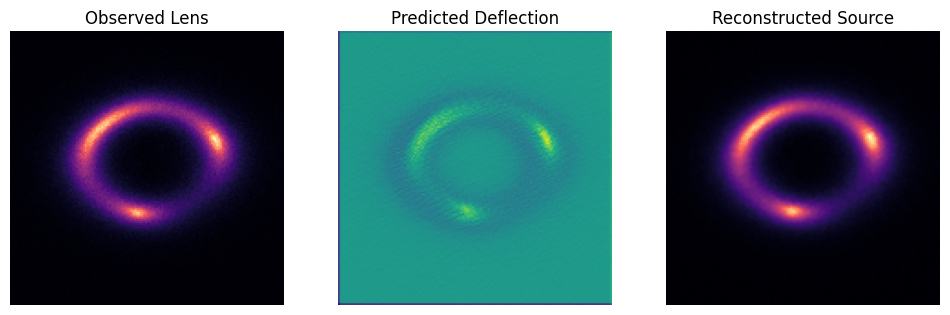

In [16]:
# Visualize one example
imgs, _ = next(iter(val_loader))
sample_img = imgs[:1].to(device)

with torch.no_grad():
    defl = model.deflection_net(sample_img).permute(0, 2, 3, 1)
    recon = model.physics_engine(sample_img, defl)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1); plt.title("Observed Lens"); plt.imshow(sample_img[0,0].cpu(), cmap='magma'); plt.axis('off')
plt.subplot(1, 3, 2); plt.title("Predicted Deflection"); plt.imshow(torch.norm(defl[0], dim=-1).cpu(), cmap='viridis'); plt.axis('off')
plt.subplot(1, 3, 3); plt.title("Reconstructed Source"); plt.imshow(recon[0,0].cpu(), cmap='magma'); plt.axis('off')
plt.show()

In [ ]:
from IPython.display import FileLink

# 
weights_file = 'DeepLense_PINN_Final.pth'

if os.path.exists(weights_file):
    display(FileLink(weights_file))
    print("Click the link above to download  model weights.")
else:
    print("File not found. Make sure you ran the torch.save() cell!")

/kaggle/working/DeepLense_PINN_Final.pth

Click the link above to download your model weights.


In [ ]:
# Saveing the model weights in the Kaggle working directory
torch.save(model.state_dict(), 'DeepLense_TestVII_PINN_Weights.pth')

# Verifying the file exists
import os
if os.path.exists('DeepLense_TestVII_PINN_Weights.pth'):
    print("Model weights saved successfullyr.")
else:
    print(" Error saving weights")

Model weights saved successfullyr.


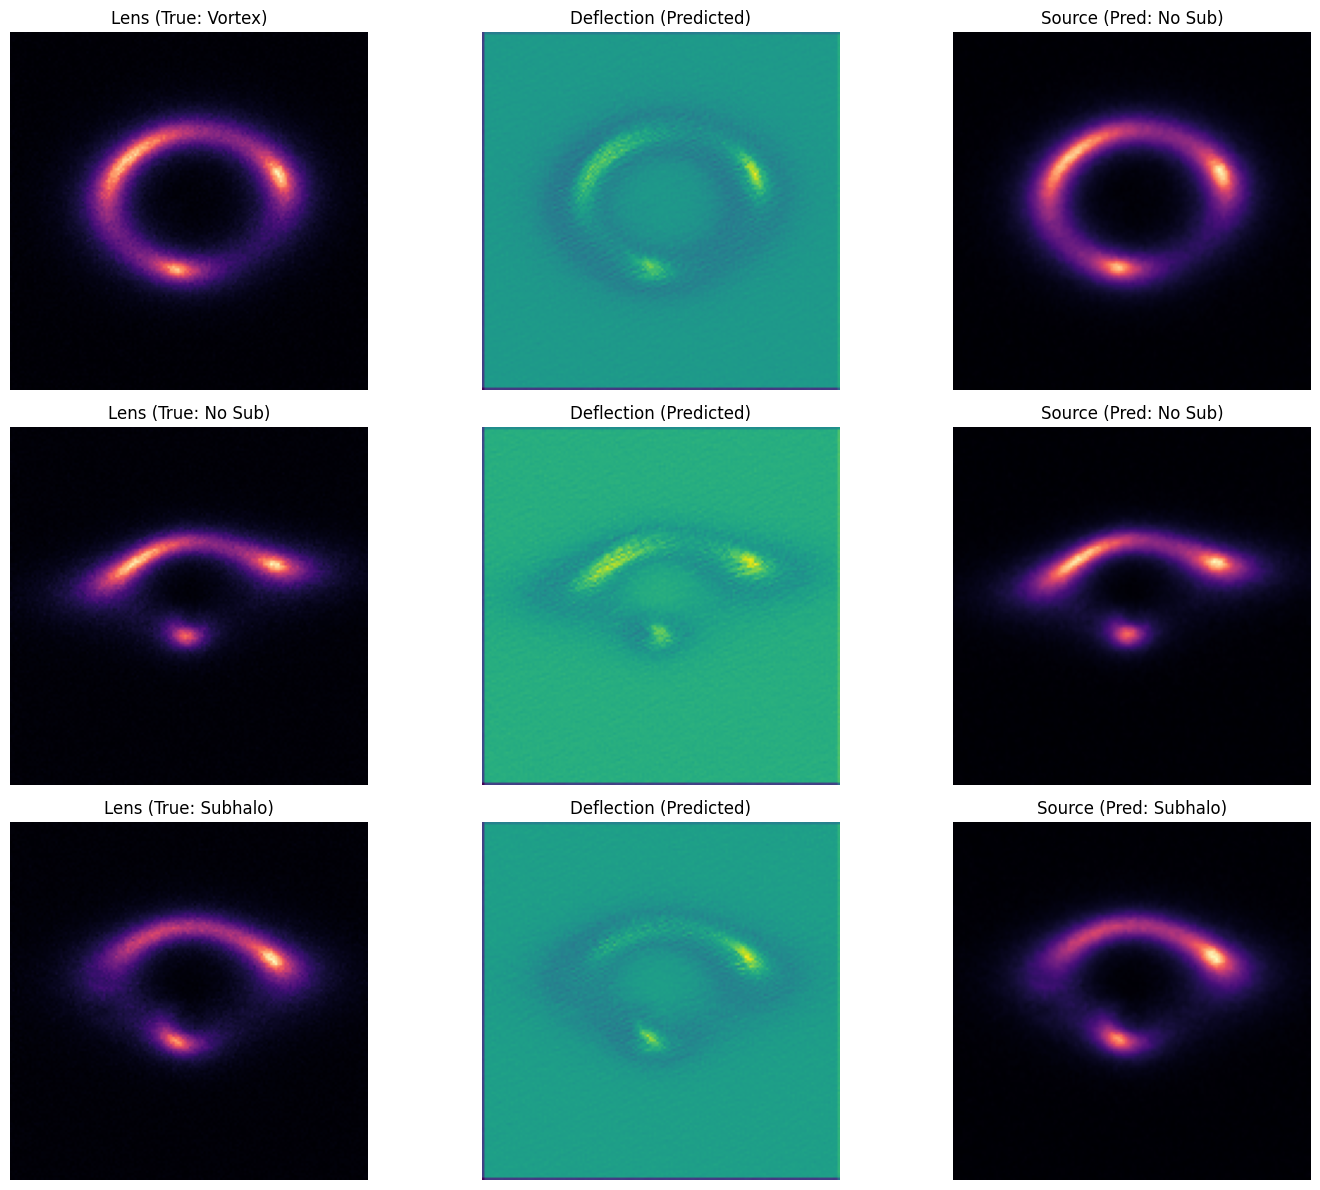

In [ ]:
import matplotlib.pyplot as plt

def show_off_pinn(model, loader, device, num_samples=3):
    model.eval()
    imgs, lbls = next(iter(loader))
    classes = ['No Sub', 'Subhalo', 'Vortex']
    
    # Grab a few samples
    samples = imgs[:num_samples].to(device)
    labels = lbls[:num_samples]
    
    with torch.no_grad():
        # Predicts the deflection (alpha)
        defl = model.deflection_net(samples).permute(0, 2, 3, 1)
        # Reconstructs the source (beta)
        recon = model.physics_engine(samples, defl)
        # Final classification
        outputs = model(samples)
        preds = torch.argmax(outputs, dim=1)

    plt.figure(figsize=(15, 4 * num_samples))
    
    for i in range(num_samples):
        # 1. Original Image
        plt.subplot(num_samples, 3, i*3 + 1)
        plt.imshow(samples[i,0].cpu(), cmap='magma')
        plt.title(f"Lens (True: {classes[labels[i]]})")
        plt.axis('off')
        
        # 2. Deflection Field (Magnitude)
        plt.subplot(num_samples, 3, i*3 + 2)
        defl_mag = torch.norm(defl[i], dim=-1).cpu()
        plt.imshow(defl_mag, cmap='viridis')
        plt.title(f"Deflection (Predicted)")
        plt.axis('off')
        
        # 3. Reconstructed Source
        plt.subplot(num_samples, 3, i*3 + 3)
        plt.imshow(recon[i,0].cpu(), cmap='magma')
        plt.title(f"Source (Pred: {classes[preds[i]]})")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Execute the visualization
show_off_pinn(model, val_loader, device)

In [22]:
print(f"Total Images: {len(data_list)}")
print(f"Training Images: {len(train_idx)}")
print(f"Validation Images: {len(val_idx)}")

Total Images: 37500
Training Images: 33750
Validation Images: 3750
